In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import netCDF4 as nc
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import pickle

import sys
sys.path.append('/home/z5297792/UNSW-MRes/MRes/SEACOFS_dataset') 
from clim_functions import plot_binned_median_map, _nice_step, _grid_step, bin_edges_fd, binned_median


In [2]:
df_eddies = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/df_eddies_processed.pkl')
df_AE = df_eddies[df_eddies.Cyc=='AE'].copy()
df_CE = df_eddies[df_eddies.Cyc=='CE'].copy()


In [3]:
# Field Data
fname = f'/srv/scratch/z3533156/26year_BRAN2020/outer_avg_01461.nc'
dataset = nc.Dataset(fname)
lon_rho = np.transpose(dataset.variables['lon_rho'], axes=(1, 0))
lat_rho = np.transpose(dataset.variables['lat_rho'], axes=(1, 0))
mask_rho = np.transpose(dataset.variables['mask_rho'], axes=(1, 0))
h = np.transpose(dataset.variables['h'], axes=(1, 0))
# f = np.transpose(dataset.variables['f'], axes=(1, 0))
angle = dataset.variables['angle'][0, 0]
z_r = np.load('/srv/scratch/z5297792/z_r.npy')
z_r = np.transpose(z_r, (1, 2, 0))
def distance(lat1, lon1, lat2, lon2):
    EARTH_RADIUS = 6357
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return EARTH_RADIUS * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
j_mid = lon_rho.shape[1] // 2
i_mid = lon_rho.shape[0] // 2
dx = distance(lat_rho[:-1, j_mid], lon_rho[:-1, j_mid],
              lat_rho[1:, j_mid], lon_rho[1:, j_mid])
dy = distance(lat_rho[i_mid, :-1], lon_rho[i_mid, :-1],
              lat_rho[i_mid, 1:], lon_rho[i_mid, 1:])
x_grid = np.insert(np.cumsum(dx), 0, 0)
y_grid = np.insert(np.cumsum(dy), 0, 0)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid, indexing='ij')

levels_lat = [-40, -35, -30, -25]
levels_lon = [150, 155, 160]


In [4]:
print(f'No. of Eddies {len(df_eddies.Eddy.unique())}, No. of Eddy-Days {len(df_eddies)}')
print(f'No. of AEs {len(df_AE.Eddy.unique())}, No. of AE-Days {len(df_AE)}')
print(f'No. of CEs {len(df_CE.Eddy.unique())}, No. of CE-Days {len(df_CE)}')


No. of Eddies 3842, No. of Eddy-Days 157798
No. of AEs 1916, No. of AE-Days 81040
No. of CEs 1926, No. of CE-Days 76758


In [5]:
print('Profiles used for tilt')
print(f'No. of Eddy-Days {len(df_eddies)-6*len(df_eddies.Eddy.unique())}')
print(f'No. of AE-Days {len(df_AE)-6*len(df_AE.Eddy.unique())}')
print(f'No. of CE-Days {len(df_CE)-6*len(df_CE.Eddy.unique())}')


Profiles used for tilt
No. of Eddy-Days 134746
No. of AE-Days 69544
No. of CE-Days 65202


In [6]:
print(f'Oldest AE was {df_AE.Age.max()}')
print(f'Oldest CE was {df_CE.Age.max()}')


Oldest AE was 463
Oldest CE was 210


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


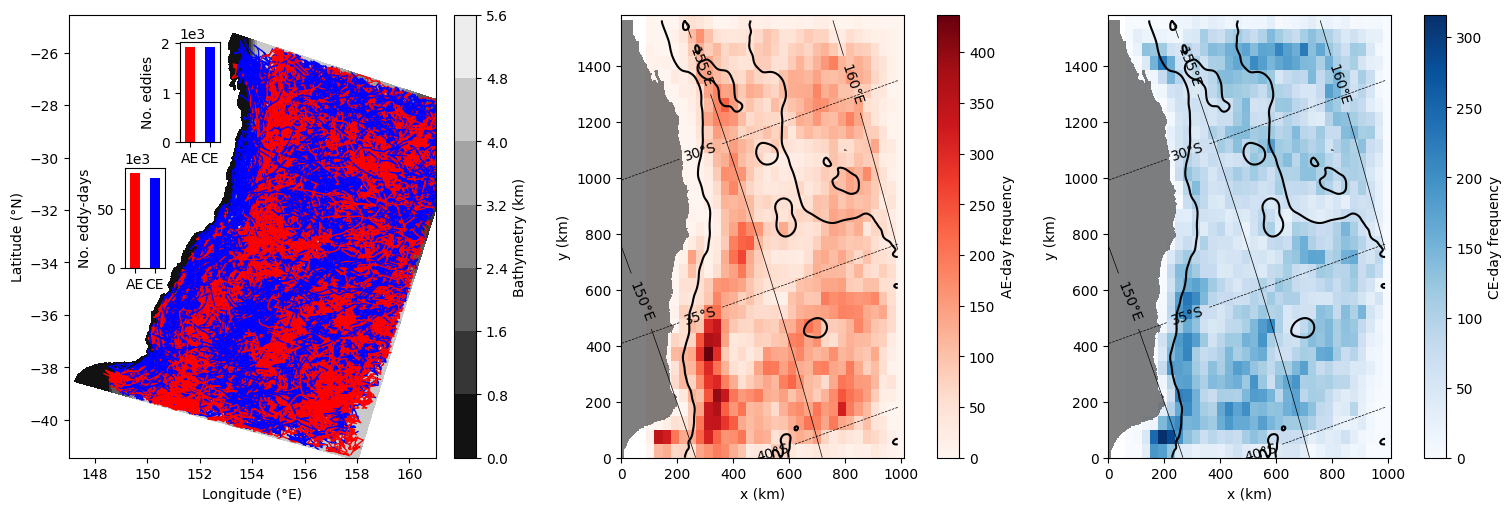

In [7]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

# --- Panel 1: Map with eddy tracks and insets ---
ax = axs[0]
cs = ax.contourf(lon_rho, lat_rho, np.where(mask_rho, h/1000, np.nan), cmap='grey')
fig.colorbar(cs, ax=ax, label='Bathymetry (km)')

for eddy in df_eddies.Eddy.unique():
    d = df_eddies[df_eddies.Eddy == eddy]
    # ax.plot(d.Lon, d.Lat, lw=1, alpha=1)
    cyc = d.iloc[0].Cyc
    ax.plot(d.lon, d.lat, color='r' if cyc=='AE' else 'b', lw=1, alpha=1)

ax.axis('equal')
ax.set_xlim(148, 160)
ax.set_ylim(-40, -26)
ax.set_xlabel('Longitude (°E)')
ax.set_ylabel('Latitude (°N)')

# Inset 1: Eddy counts
df_unique = df_eddies[['Eddy', 'Cyc']].drop_duplicates()
in_ax1 = inset_axes(ax, width=.4, height=1, loc='center',
                   bbox_to_anchor=(152, -27.5, 0, 0),
                   bbox_transform=ax.transData, borderpad=0)
counts = df_unique['Cyc'].value_counts().reindex(['AE','CE']).fillna(0)
counts.plot(kind='bar', color=['r','b'], ax=in_ax1)
in_ax1.set_xlabel('')
in_ax1.set_ylabel('No. eddies')
in_ax1.tick_params(axis='x', rotation=0)
in_ax1.ticklabel_format(axis='y', style='sci', scilimits=(3, 3))
in_ax1.set_facecolor('none')

# Inset 2: Eddy-day counts
in_ax2 = inset_axes(ax, width=.4, height=1, loc='center',
                   bbox_to_anchor=(149.9, -32.3, 0, 0),
                   bbox_transform=ax.transData, borderpad=0)
counts = df_eddies['Cyc'].value_counts().reindex(['AE','CE']).fillna(0)
counts.plot(kind='bar', color=['r','b'], ax=in_ax2)
in_ax2.set_xlabel('')
in_ax2.set_ylabel('No. eddy-days')
in_ax2.tick_params(axis='x', rotation=0)
in_ax2.ticklabel_format(axis='y', style='sci', scilimits=(3, 3))
in_ax2.set_facecolor('none')

# --- Panel 2 & 3: Eddy-day distributions ---
for d, subset in enumerate([df_eddies[df_eddies.Cyc == 'AE'], df_eddies[df_eddies.Cyc == 'CE']]):
    eddy_x = subset.xc.to_numpy()
    eddy_y = subset.yc.to_numpy()

    x_edges = bin_edges_fd(eddy_x, X_grid, rule='fd')  # or rule='scott'/'fd'
    y_edges = bin_edges_fd(eddy_y, Y_grid, rule='fd')
    # print(f'x-bin size: {np.mean(np.diff(x_edges))}')
    # print(f'y-bin size: {np.mean(np.diff(y_edges))}')

    H, _, _ = np.histogram2d(eddy_y, eddy_x, bins=[y_edges, x_edges])

    pcm = axs[d+1].pcolormesh(x_edges, y_edges, H, cmap='Reds' if d==0 else 'Blues')
    fig.colorbar(pcm, ax=axs[d+1], label='AE-day frequency' if d==0 else 'CE-day frequency')

    axs[d+1].contourf(X_grid, Y_grid, np.where(mask_rho == 0, 1, np.nan),
                      levels=[0.5, 1.5], colors=['k'], alpha=.5)

    c1 = axs[d+1].contour(X_grid, Y_grid, lat_rho, levels=[-40, -35, -30, -25], colors='k', linewidths=.5)
    axs[d+1].clabel(c1, fmt=lambda v: f"{np.abs(v):.0f}°S", inline=True, colors='k')
    c2 = axs[d+1].contour(X_grid, Y_grid, lon_rho, levels=[150, 155, 160], colors='k', linewidths=.5)
    axs[d+1].clabel(c2, fmt=lambda v: f"{v:.0f}°E", inline=True, colors='k')

    axs[d+1].set_xlabel('x (km)')
    axs[d+1].set_ylabel('y (km)')
    axs[d+1].set_aspect('equal')
    axs[d+1].contour(X_grid, Y_grid, h, levels=[4000], colors='k')

# plt.tight_layout()
plt.show()


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


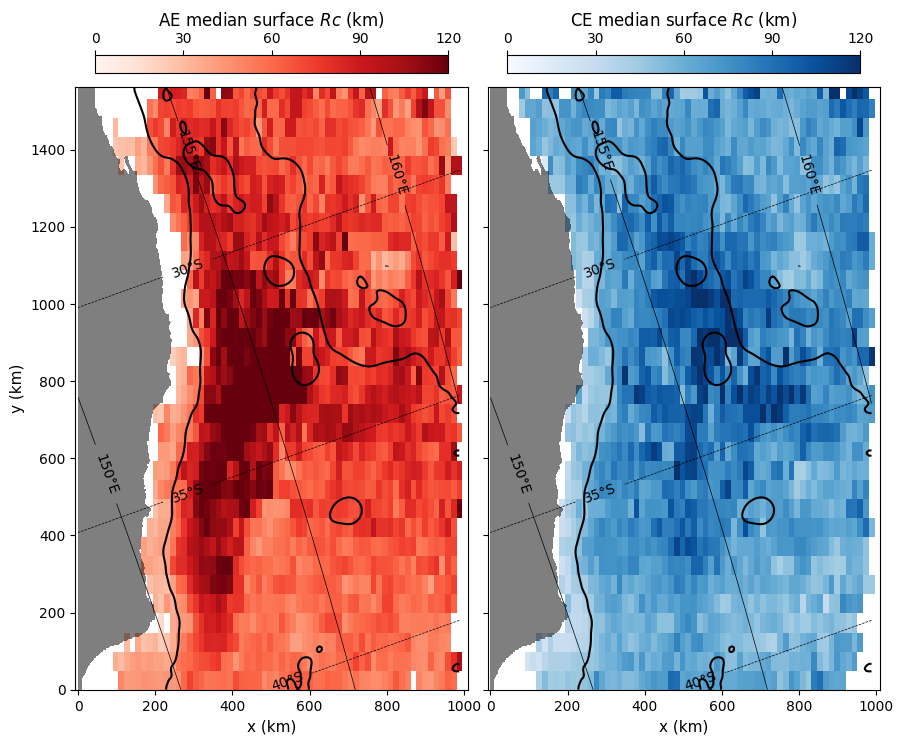

In [8]:
fig, axs = plot_binned_median_map(df_eddies, metric='Rc', vmin=0, vmax=120)


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


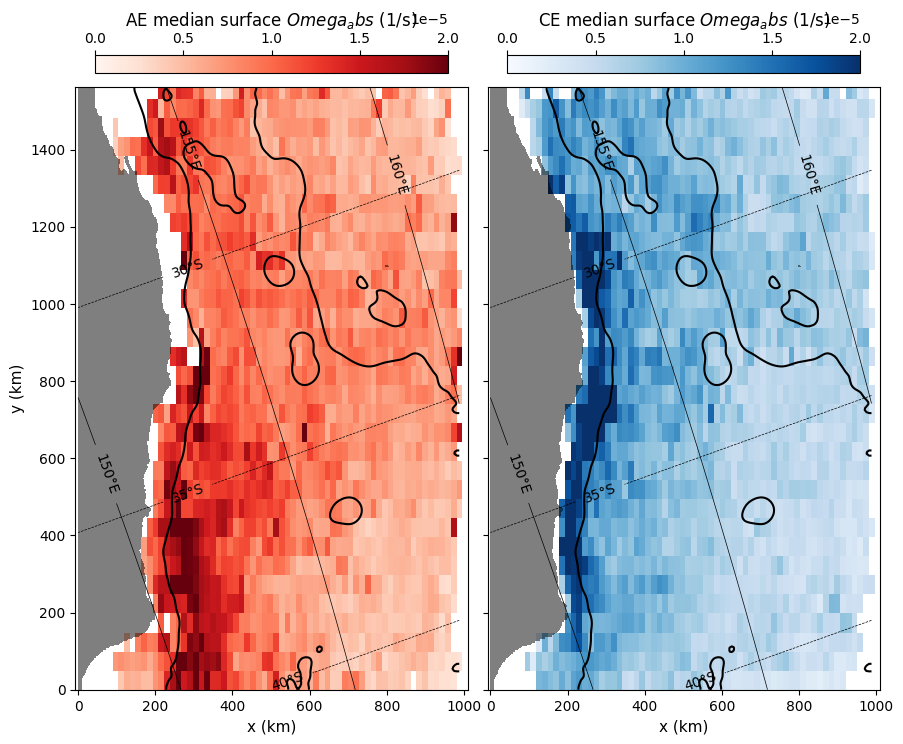

In [9]:
df_eddies['Omega_abs'] = df_eddies.Omega.abs()
fig, axs = plot_binned_median_map(df_eddies, metric='Omega_abs', vmin=0, vmax=2e-5, units='1/s')


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


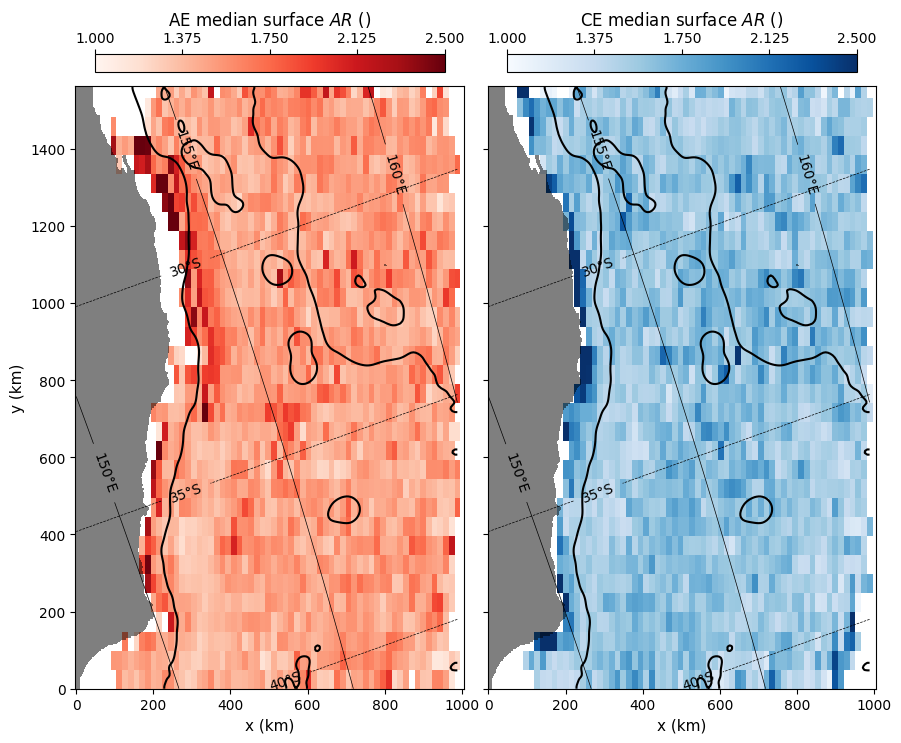

In [10]:
fig, axs = plot_binned_median_map(df_eddies, metric='AR', vmin=1, vmax=2.5, units='')


In [11]:
with open('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/dic_vert_doppio.pkl', 'rb') as f:
    dic_vert = pickle.load(f)
    

In [12]:
depths = []
for k in range(len(df_eddies)):
    data = df_eddies.iloc[k]
    df = dic_vert[f'Eddy{data.Eddy}'][f'Day{data.Day}']
    if len(df):
        depths.append(np.abs(df.iloc[-1].Depth)/1e3)
    else:
        depths.append(0)
df_eddies['zmax'] = depths
zmax_idx = [np.argmin(np.abs(np.abs(z_r[150,150,:])/1e3 - z)) for z in df_eddies.zmax]
df_eddies['zmax_idx'] = zmax_idx


KeyError: 'Day1672'

In [ ]:
eddy_props = []
for eddy in df_eddies.Eddy.unique():
    df = df_eddies[df_eddies.Eddy==eddy].copy()
    eddy_props.extend(np.array(np.hypot(df.xc.diff(), df.yc.diff()) * 0.011574))
df_eddies['EddyProp'] = eddy_props


In [ ]:
fig, axs = plt.subplots(8, 1, figsize=(10, 18))

def clean(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    return a[np.isfinite(a)], b[np.isfinite(b)]

def shared_bins(a, b, method='fd', min_bins=12, max_bins=40):
    a, b = clean(a, b)
    all_vals = np.concatenate([a, b])
    
    if all_vals.size == 0:
        return np.linspace(0, 1, min_bins + 1)
    if np.all(all_vals == all_vals[0]):
        return np.linspace(all_vals[0] - 0.5, all_vals[0] + 0.5, min_bins + 1)

    edges = np.histogram_bin_edges(all_vals, bins=method)
    n_bins = len(edges) - 1

    if n_bins < min_bins:
        edges = np.linspace(all_vals.min(), all_vals.max(), min_bins + 1)
    elif n_bins > max_bins:
        edges = np.linspace(all_vals.min(), all_vals.max(), max_bins + 1)

    return edges

def mirrored_hist(ax, ae, ce, bins, xlabel, ylabel, ylim=None, xlim=None, mirror_flag=True):
    ae, ce = clean(ae, ce)

    ax.hist(ae, bins=bins, color='r')
    counts, edges = np.histogram(ce, bins=bins)
    if mirror_flag:
        ax.bar(edges[:-1], -counts, width=np.diff(edges), color='b', align='edge')
    else:
        ax.bar(edges[:-1], counts, width=np.diff(edges), color='b', align='edge')

    ax.axhline(0, color='k', linewidth=1)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_yticks(ax.get_yticks())
    ax.set_yticklabels([abs(int(t)) for t in ax.get_yticks()])

    if ylim is not None:
        ax.set_ylim(ylim)
    if xlim is not None:
        ax.set_xlim(xlim)

# --- Plot 0: Age ---
ae = df_eddies.loc[df_eddies.Cyc == 'AE', 'Age']
ce = df_eddies.loc[df_eddies.Cyc == 'CE', 'Age']
bins0 = shared_bins(ae, ce, method='fd', min_bins=20, max_bins=50)
mirrored_hist(
    axs[0], ae, ce, bins0,
    'Lifespan (days)', 'Number of eddies',
    ylim=(-25000, 25000)
)

# --- Plot 1: Lat ---
ae = df_eddies.loc[df_eddies.Cyc == 'AE', 'lat']
ce = df_eddies.loc[df_eddies.Cyc == 'CE', 'lat']
bins1 = shared_bins(ae, ce, method='fd', min_bins=20, max_bins=50)
mirrored_hist(
    axs[1], ae, ce, bins1,
    'Latitude (°N)', 'Number of eddy-days',
    ylim=(-4000, 4000)
)

# --- Plot 2: Propagation Distance ---
eddy_props_AE, eddy_props_CE = [], []
for eddy in df_eddies.Eddy.unique():
    df = df_eddies[df_eddies.Eddy == eddy]
    dist = np.nansum(np.hypot(df.xc.diff(), df.yc.diff()))
    if df.iloc[0].Cyc == 'AE':
        eddy_props_AE.append(dist)
    else:
        eddy_props_CE.append(dist)

bins2 = shared_bins(eddy_props_AE, eddy_props_CE, method='fd', min_bins=15, max_bins=40)
mirrored_hist(
    axs[2], eddy_props_AE, eddy_props_CE, bins2,
    'Propagation distance (km)', 'Number of eddies',
    ylim=(-450, 450)
)

# --- Plot 3: Propagation Speed ---
dfAE = df_eddies[df_eddies.Cyc == 'AE'].copy().dropna()
dfAE = dfAE[dfAE.EddyProp <= 1]
dfCE = df_eddies[df_eddies.Cyc == 'CE'].copy().dropna()
dfCE = dfCE[dfCE.EddyProp <= 1]

bins3 = shared_bins(dfAE.EddyProp, dfCE.EddyProp, method='fd', min_bins=15, max_bins=40)
mirrored_hist(
    axs[3], dfAE.EddyProp, dfCE.EddyProp, bins3,
    r'Propagation speed (ms$^{-1}$)', 'Number of eddies',
    ylim=(-13000, 13000)
)

# --- Plot 4: Vorticity ---
df_v = df_eddies[df_eddies.w.abs() <= 8e-5]
ae = df_v.loc[df_v.Cyc == 'AE', 'w']
ce = df_v.loc[df_v.Cyc == 'CE', 'w']
bins4 = shared_bins(ae, ce, method='fd', min_bins=20, max_bins=50)
mirrored_hist(
    axs[4], ae, ce, bins4,
    r'Surface vorticity (s$^{-1}$)', 'Number of eddy-days',
    xlim=(-8e-5, 8e-5),
    mirror_flag=False
)

# --- Plot 5: Radius ---
ae = df_eddies.loc[df_eddies.Cyc == 'AE', 'Rc']
ce = df_eddies.loc[df_eddies.Cyc == 'CE', 'Rc']
bins5 = shared_bins(ae, ce, method='fd', min_bins=20, max_bins=50)
mirrored_hist(
    axs[5], ae, ce, bins5,
    r'Surface core radius (km)', 'Number of eddy-days',
    ylim=(-7500, 7500)
)

# --- Plot 6: Depth ---
bin_int = 1
max_depth_km = 5
edges = np.arange(0, max_depth_km + bin_int, bin_int)

def _fmt(x):
    return f"{x:.0f}" if float(bin_int).is_integer() else f"{x:.1f}"

bin_labels = (
    ["Depth = 0", f"({_fmt(edges[0])}–{_fmt(edges[0] + bin_int)})"]
    + [f"[{_fmt(b)}–{_fmt(b+bin_int)})" for b in edges[1:-1]]
)
bin_labels[-1] = f"[{_fmt(edges[-2])}–{_fmt(edges[-1])}]"

ae_raw = df_eddies.loc[df_eddies.Cyc == 'AE', 'zmax'].dropna().to_numpy()
ce_raw = df_eddies.loc[df_eddies.Cyc == 'CE', 'zmax'].dropna().to_numpy()

ae = ae_raw[(ae_raw >= edges[0]) & (ae_raw <= edges[-1])]
ce = ce_raw[(ce_raw >= edges[0]) & (ce_raw <= edges[-1])]

ae0 = int(np.isclose(ae, 0).sum())
ce0 = int(np.isclose(ce, 0).sum())

ae_nz = ae[~np.isclose(ae, 0)]
ce_nz = ce[~np.isclose(ce, 0)]

ae_counts, _ = np.histogram(ae_nz, bins=edges)
ce_counts, _ = np.histogram(ce_nz, bins=edges)

ae_counts = np.insert(ae_counts, 0, ae0)
ce_counts = np.insert(ce_counts, 0, ce0)

ax = axs[6]
xpos = np.arange(len(bin_labels))
ax.bar(xpos,  ae_counts, color='r')
ax.bar(xpos, -ce_counts, color='b')

ax.axhline(0, color='k', linewidth=1)
m = max(1, int(max(ae_counts.max(), ce_counts.max()) * 1.1))
ax.set_xticks(xpos)
ax.set_xticklabels(bin_labels, rotation=45, ha='right')
ax.set_xlabel('Depth bin (km)')
ax.set_ylabel('Number of eddy-days')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_yticks(ax.get_yticks())
ax.set_yticklabels([abs(int(t)) for t in ax.get_yticks()])
ax.set_ylim(-m, m)

# --- Plot 7: Aspect ratio ---
df_a = df_eddies[df_eddies.AR <= 5]
ae = df_a.loc[df_a.Cyc == 'AE', 'AR']
ce = df_a.loc[df_a.Cyc == 'CE', 'AR']
bins7 = shared_bins(ae, ce, method='fd', min_bins=15, max_bins=40)
mirrored_hist(
    axs[7], ae, ce, bins7,
    'Surface aspect ratio', 'Number of eddy-days',
    ylim=(-11000, 11000)
)

plt.tight_layout()
plt.show()
